<a href="https://colab.research.google.com/github/DowntonCrabby/Data557_GroupProject_CapeTown/blob/main/Data557_FinalProject_Q2_DataStory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sex-Based Discrimination in Promotion from Associate Professor to Full Professor

### DATA 557 Final Project  

This interactive data story examines whether sex-based disparities exist in promotion from Associate Professor to Full Professor using historical faculty salary and rank data from a major university.

## Objective

The goal of this analysis is to evaluate whether **sex-based disparities exist in promotion from Associate Professor to Full Professor**.
Promotion inequality can appear in several ways. Faculty may experience different:

* probabilities of promotion
* timelines to promotion
* salary outcomes when promotion occurs

To capture these possibilities, this analysis evaluates three complementary research questions:

1. **Probability of promotion**  
   Are women less likely than men to be promoted from Associate Professor to Full Professor?

2. **Time to promotion**  
   Among faculty who are promoted, do women take longer to reach Full Professor?

3. **Salary differences at promotion**  
   When promotion occurs, do women receive smaller salary increases than men?

By examining promotion through these three lenses, we can evaluate whether disparities appear in access to promotion, the speed of promotion, or the compensation associated with promotion.

## Background and Research Question

Promotion to Full Professor represents one of the most significant milestones in an academic career. Differences in promotion outcomes across demographic groups can therefore have long-term implications for career advancement, income, and representation in senior academic ranks.

The dataset used in this analysis contains annual records for faculty members over a 20-year period. Each row represents a faculty member in a particular year. Because the data are recorded annually, they allow us to reconstruct career trajectories and identify promotion events.

The central research question of this project is:

> **Does sex based wage discrimation exist in promotions from Associate Professor to Full Professor?**

Sex based wage disparities can emerge through several mechanisms. A simple comparison of salary adjustments when promoted from associate professor to full professor is likely insufficient to capture the full picture of all the subtle and insidious manifestations of discrimination. For example, promotion opportunities may be disproportionately afforded to one group over another, artifically capping faculty's potential earnings. Alternately, faculty from different groups may have similar eventual promotion rates but experience systematically longer waits before promotion, which can delay access to higher salaries, leadership roles, and professional recognition.

To capture these possibilities, this project evaluates promotion outcomes across three complementary dimensions. Each dimension reflects a different aspect of the promotion process and helps identify distinct forms of potential disparity. The probability of promotion examines whether faculty members differ in whether they are promoted during the observation period. The time required to reach promotion evaluates whether some faculty must wait longer to achieve the same advancement. Finally, salary changes associated with promotion assess whether the financial rewards of promotion differ across groups once promotion occurs.


So in brief, rather than focusing on a single outcome, this project evaluates promotion disparities across three dimensions:

**1. likelihood of promotion**  
**2. time required to reach promotion**  
**3. salary changes associated with promotion**

Examining these outcomes together provides a more complete picture of potential inequities in academic advancement.

### Data Cleaning Summary

The dataset was cleaned and prepared to support longitudinal analysis of faculty promotion and salary trajectories.

First, the dataset was loaded into a pandas dataframe using whitespace as the delimiter, and `"NA"` values were treated as missing. Initial inspection steps such as `info()`, `describe()`, and `unique()` checks were performed to understand the structure of the data, verify variable types, and review the coding of categorical variables including rank, sex, field, and degree. Column names were also stripped of leading and trailing whitespace to prevent formatting issues.

Next, records with missing values in the `rank` variable were removed because rank information is required to analyze promotion trajectories. The dataset was then examined to determine how many observations existed for each faculty member. Faculty appearing in only a single year were removed, since the analysis requires multiple observations over time to study changes in rank or salary.

The remaining records were sorted by faculty ID and year so that each individual’s observations followed chronological order. Rank histories were then constructed for each faculty member to examine how ranks changed over time.

Ranks were encoded numerically (`Assist = 1`, `Assoc = 2`, `Full = 3`) to check for inconsistencies in promotion trajectories. A validation step flagged any cases where rank decreased over time, which would indicate an invalid career progression. One anomalous faculty record with a backward rank movement was identified and removed from the dataset.

After these steps, the cleaned dataset contained only faculty with valid rank information, multiple years of observations, and consistent promotion trajectories. The final cleaned dataset was saved for use in the subsequent statistical analysis.

---

# Coding Setup

---

#### Imports

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from patsy import dmatrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

#### Load Data

In [4]:
salary_long_df = pd.read_csv('cleaned_longitudinal_dataset.csv')
salary_long_df

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary,rank_order
0,2,2,M,Other,91,Other,94,94,Assist,0,4743.0,1
1,3,2,M,Other,91,Other,94,95,Assist,0,4881.0,1
2,5,6,M,PhD,66,Other,91,91,Full,1,11182.0,3
3,6,6,M,PhD,66,Other,91,92,Full,1,11507.0,3
4,7,6,M,PhD,66,Other,91,93,Full,0,11840.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
19691,19788,1770,M,Other,51,Other,64,91,Full,0,5318.0,3
19692,19789,1770,M,Other,51,Other,64,92,Full,0,5472.0,3
19693,19790,1770,M,Other,51,Other,64,93,Full,0,5551.0,3
19694,19791,1770,M,Other,51,Other,64,94,Full,0,5551.0,3


### Plotting Aesthetics

In [5]:
SEX_COLOR_PALETTE = {
    "F": "#f1a340",
    "M": "#998ec3"}

---
# Constructing the Analysis Datasets
---
The full dataset contains longitudinal records for faculty members across many years and academic ranks. However, not all observations are relevant for the research question addressed in this project.

Because the analysis focuses on promotion from Associate Professor to Full Professor, the next step is to construct analysis datasets that isolate the faculty members and observations relevant to this transition.

This process involves identifying faculty who are observed at the Associate Professor rank and determining whether and when they transition to Full Professor.


### **Subset Data**
**Identifying faculty observed at the Associate Professor rank**

Because this project studies promotion from Associate Professor to Full Professor, the relevant population consists of faculty members who are observed at the Associate Professor rank at least once in the dataset.

Faculty who are never observed at the Associate rank cannot experience the promotion of interest and are therefore excluded from the promotion analysis population.

In [6]:
associate_ids = (salary_long_df
                 .loc[salary_long_df["rank"] == "Assoc", "id"]
                 .unique())

associate_df = salary_long_df[salary_long_df["id"].isin(associate_ids)].copy()

print("Number of faculty who ever become Associate:", len(associate_ids))
print("Subset shape (all years for those faculty):", associate_df.shape)

Number of faculty who ever become Associate: 979
Subset shape (all years for those faculty): (14167, 12)


#### Identify faculty promoted to full

In [7]:
promoted_ids = (associate_df
                .loc[associate_df["rank"] == "Full", "id"]
                .unique())

print("Faculty promoted to Full:", len(promoted_ids))

Faculty promoted to Full: 546


### **Constructing faculty promotion summary variables**

The original dataset is structured as a longitudinal panel of person–year observations, where each row represents a faculty member in a specific year. While this format is useful for tracking changes over time, the promotion analyses in this project require a faculty-level view that summarizes each individual's career trajectory.

These measures allow us to quantify several aspects of the promotion process, including whether promotion occurred, how long it took to occur, and how salaries changed when promotion took place. By aggregating the longitudinal records into these summary variables, we create a dataset that can be used consistently across our three approaches to answering this question, and a dataset that can be used for plotting.

The summary dataset includes:

- `promoted`: bool, true if the faculty is promoted from associate to full  
- `assoc_yr_first`: first year a faculty member is observed at the Associate Professor rank  
- `assoc_yr_last`: last year a faculty member is observed at the Associate Professor rank, used to identify the final Associate observation prior to promotion
- `assoc_yrs_observed`: the number of years observed at associate rank. This is calculated as the difference between the last observed Associate year (`assoc_yr_last`) and the first observed Associate year (`assoc_yr_first`). It reflects the amount of time during which promotion could occur.
- `assoc_sal_last`: the final salary observed while at the Associate rank  
- `full_yr_first`: the first year the faculty member is observed at the Full Professor rank  
- `full_sal_first`: the salary in the first year at the Full rank  
- `yrs_to_promo`: the number of years between the first observed Associate year and the first observed Full year, measuring time to promotion  
- `promo_sal_change`: the change in salary associated with promotion, calculated as the difference between `full_sal_first` and `assoc_sal_last`
- `sal_change_pct`: the salary change in percentage, meant to help normalize differences in salaries across time and fields etc.
- `assoc_cohort`: a categorical variable based on `assoc_yr_first` that groups faculty into Associate Professor entry cohorts. This is used to account for differences in promotion environments across time periods rather than treating calendar year as a purely linear effect.


#### Calculate Summary Variables

In [8]:
# Sort Records
associate_df = associate_df.sort_values(["id", "year"]).copy()

# Calculate  variables
promotion_indicator_df = (associate_df.groupby("id")["rank"]
                          .apply(lambda x: (x == "Full").any())
                          .astype(int)
                          .reset_index(name="promoted"))

first_assoc_year_df = (associate_df[associate_df["rank"] == "Assoc"]
                       .groupby("id")["year"]
                       .min()
                       .reset_index(name="assoc_yr_first"))

assoc_last_df = (associate_df[associate_df["rank"] == "Assoc"]
                 .groupby("id")["year"]
                 .max()
                 .reset_index(name="assoc_yr_last"))

full_first_df = (associate_df[associate_df["rank"] == "Full"]
                 .groupby("id")["year"]
                 .min()
                 .reset_index(name="full_yr_first"))

last_assoc_salary_df = (associate_df[associate_df["rank"] == "Assoc"]
                        .sort_values(["id", "year"])
                        .groupby("id")
                        .tail(1)[["id", "salary"]]
                        .rename(columns={"salary": "assoc_sal_last"}))

first_full_salary_df = (associate_df[associate_df["rank"] == "Full"]
                        .sort_values(["id", "year"])
                        .groupby("id")
                        .head(1)[["id", "salary"]]
                        .rename(columns={"salary": "full_sal_first"}))

#### Merge promotion summary variables

In [9]:
promotion_summary_df = first_assoc_year_df.merge(
    assoc_last_df,
    on="id",
    how="left")

promotion_summary_df = promotion_summary_df.merge(
    full_first_df,
    on="id",
    how="left")

promotion_summary_df = promotion_summary_df.merge(
    last_assoc_salary_df,
    on="id",
    how="left")

promotion_summary_df = promotion_summary_df.merge(
    first_full_salary_df,
    on="id",
    how="left")

promotion_summary_df = promotion_summary_df.merge(
    promotion_indicator_df,
    on="id",
    how="left")

print("Rows in promotion summary dataset:", promotion_summary_df.shape[0])
promotion_summary_df.head()

Rows in promotion summary dataset: 979


,id,assoc_yr_first,assoc_yr_last,full_yr_first,assoc_sal_last,full_sal_first,promoted
0,7,79,95,NaN,4604.0,NaN,0
1,9,90,95,NaN,5472.0,NaN,0
2,10,80,92,93.0,6781.0,7180.0,1
3,13,76,81,82.0,3137.0,3322.0,1
4,14,92,93,94.0,8770.0,9025.0,1


####  Add derived promotion measures

In [10]:
promotion_summary_df["yrs_to_promo"] = (
    promotion_summary_df["full_yr_first"] - promotion_summary_df["assoc_yr_first"])

promotion_summary_df["promo_sal_change"] = (
    promotion_summary_df["full_sal_first"] - promotion_summary_df["assoc_sal_last"])

promotion_summary_df["assoc_yrs_observed"] = (
    promotion_summary_df["assoc_yr_last"] - promotion_summary_df["assoc_yr_first"])

promotion_summary_df["sal_change_pct"] = (
    promotion_summary_df["promotion_diff"] / promotion_summary_df["prev_salary"])

In [11]:
promotion_summary_df["assoc_cohort"] = pd.cut(
    promotion_summary_df["assoc_yr_first"],
    bins=[75, 80, 85, 90, 95],
    labels=["76-80", "81-85", "86-90", "91-95"],
    right=True,
    include_lowest=True)

promotion_summary_df["assoc_cohort"].value_counts(dropna=False).sort_index()

,count
assoc_cohort,
76-80,351
81-85,188
86-90,221
91-95,219


## **Timing diagnostics and censoring indicators**

Because the dataset contains annual observations over a fixed time window (1976–1995), it is possible that some promotion events are only partially observed. We therefore construct several timing diagnostics to verify that promotion transitions are captured correctly and to identify cases where the observation window may limit what we can infer about promotion timing.

- `assoc_full_gap`: The difference between `full_yr_first` and `assoc_yr_last`. This measures the gap between the final observed Associate year and the first observed Full year.

- `clean_assoc_full_transition`: A boolean indicator equal to `True` when `assoc_full_gap == 1`, indicating that the promotion from Associate to Full is observed in consecutive years in the dataset. This helps confirm that the promotion event is observed cleanly in the annual records.

- `assoc_left_censored`: An indicator for whether the first observed Associate Professor year is 1976, the first year covered by the dataset. When this occurs, the true start of the Associate rank may have occurred before the observation window began, meaning the observed time to promotion may underestimate the true duration.

Together, these variables help ensure that promotion timing and salary changes are interpreted appropriately given the limits of the observation period.

#### Note about Promotion Followup Time & "Right tail bias":
- Someone who became Associate in 1995 has zero follow-up time.
- Someone who became Associate in 1994 has at most one year of follow-up.
- Someone who became Associate in 1976 has nearly 20 years of follow-up.

**Discussion**
While we initially thought about including a variable to capture whether there was right censoring in the data (i.e
An indicator for faculty who are observed at the Associate rank but are never observed at the Full rank before the dataset ends in 1995. Promotion may occur after the observation window, but it is not observed in the available data). That information is already captured by our `promotoed` variable, so we did not include it as a separate variable here.


#### Add Measures to Dataframe

In [12]:
promotion_summary_df["assoc_left_censored"] = (
    promotion_summary_df["assoc_yr_first"] == 76)

promotion_summary_df["assoc_full_gap"] = (
    promotion_summary_df["full_yr_first"] - promotion_summary_df["assoc_yr_last"])

promotion_summary_df["clean_assoc_full_transition"] = (
    promotion_summary_df["assoc_full_gap"] == 1)

promotion_summary_df.head()

,id,assoc_yr_first,assoc_yr_last,full_yr_first,assoc_sal_last,full_sal_first,promoted,yrs_to_promo,promo_sal_change,assoc_yrs_observed,assoc_cohort,assoc_left_censored,assoc_full_gap,clean_assoc_full_transition
0,7,79,95,NaN,4604.0,NaN,0,NaN,NaN,16,76-80,False,NaN,False
1,9,90,95,NaN,5472.0,NaN,0,NaN,NaN,5,86-90,False,NaN,False
2,10,80,92,93.0,6781.0,7180.0,1,13.0,399.0,12,76-80,False,1.0,True
3,13,76,81,82.0,3137.0,3322.0,1,6.0,185.0,5,76-80,True,1.0,True
4,14,92,93,94.0,8770.0,9025.0,1,2.0,255.0,1,91-95,False,1.0,True


**Lets view some basic information about our dataset now**

In [13]:
promotion_summary_df["promoted"].value_counts()

,count
promoted,
1,546
0,433


In [14]:
promotion_summary_df["assoc_left_censored"].value_counts()

,count
assoc_left_censored,
False,773
True,206


In [15]:
promotion_summary_df["clean_assoc_full_transition"].value_counts()

,count
clean_assoc_full_transition,
True,533
False,446


In [16]:
pd.crosstab(
    promotion_summary_df["promoted"],
    promotion_summary_df["clean_assoc_full_transition"],
    rownames=["Promoted"],
    colnames=["Clean transition"])

Clean transition,False,True
Promoted,,
0,433,0
1,13,533


In [17]:
diagnostic_summary = pd.DataFrame({
    "Total faculty": [promotion_summary_df.shape[0]],
    "Promoted": [promotion_summary_df["promoted"].sum()],
    "Not promoted": [(~promotion_summary_df["promoted"]).sum()],
    "Left censored": [promotion_summary_df["assoc_left_censored"].sum()],
    "Clean transitions": [promotion_summary_df["clean_assoc_full_transition"].sum()]})

diagnostic_summary

,Total faculty,Promoted,Not promoted,Left censored,Clean transitions
0,979,546,-1525,206,533


## **Faculty-level time-invariant variables**

In addition to promotion timing and salary variables, the summary dataset includes several **time-invariant faculty characteristics** recorded in the original dataset. These variables describe attributes of each faculty member that do not change across yearly observations and therefore only need to be recorded once per individual.

Including these variables in the faculty-level summary dataset allows us to examine whether promotion outcomes differ across demographic or professional characteristics. They will later serve as explanatory variables in the statistical analyses evaluating promotion probability, time to promotion, and salary changes associated with promotion.

The time-invariant variables retained from the original dataset include:

- `id`: unique identifier for each faculty member  
- `sex`: faculty member sex  
- `deg`: highest degree earned  
- `yrdeg`: year the highest degree was obtained  
- `field`: academic field category  
- `startyr`: year the faculty member began their appointment

These variables provide the contextual information needed to evaluate whether differences in promotion outcomes are associated with faculty characteristics such as sex, academic discipline, or career stage.

In [18]:
time_invariant_df = (associate_df
                     .sort_values(["id", "year"])
                     .groupby("id")[["sex", "deg", "yrdeg", "field", "startyr"]]
                     .first()
                     .reset_index())

### Merge into the summary dataframe
promotion_summary_df = promotion_summary_df.merge(
    time_invariant_df,
    on="id",
    how="left")

promotion_summary_df

,id,assoc_yr_first,assoc_yr_last,full_yr_first,assoc_sal_last,full_sal_first,promoted,yrs_to_promo,promo_sal_change,assoc_yrs_observed,assoc_cohort,assoc_left_censored,assoc_full_gap,clean_assoc_full_transition,sex,deg,yrdeg,field,startyr
0,7,79,95,NaN,4604.0,NaN,0,NaN,NaN,16,76-80,False,NaN,False,M,PhD,70,Other,71
1,9,90,95,NaN,5472.0,NaN,0,NaN,NaN,5,86-90,False,NaN,False,M,PhD,82,Other,87
2,10,80,92,93.0,6781.0,7180.0,1,13.0,399.0,12,76-80,False,1.0,True,M,PhD,68,Arts,80
3,13,76,81,82.0,3137.0,3322.0,1,6.0,185.0,5,76-80,True,1.0,True,M,PhD,68,Prof,69
4,14,92,93,94.0,8770.0,9025.0,1,2.0,255.0,1,91-95,False,1.0,True,M,PhD,79,Other,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,1764,84,86,87.0,3487.0,4105.0,1,3.0,618.0,2,81-85,False,1.0,True,M,Other,71,Other,77
975,1765,76,80,81.0,2597.5,2797.5,1,5.0,200.0,4,76-80,True,1.0,True,M,Other,55,Arts,68
976,1766,76,77,78.0,2216.0,2256.0,1,2.0,40.0,1,76-80,True,1.0,True,M,Other,55,Arts,68
977,1768,90,95,NaN,4292.0,NaN,0,NaN,NaN,5,86-90,False,NaN,False,F,Other,70,Arts,85


 #### Merge time-invariant variables into promotion summary dataset

In [19]:
#### Re-order columns to make it easier to read
promotion_summary_df = promotion_summary_df[[
    "id",
    "sex",
    "deg",
    "yrdeg",
    "field",
    "startyr",
    "assoc_yr_first",
    "assoc_yr_last",
    "assoc_sal_last",
    "full_yr_first",
    "full_sal_first",
    "promoted",
    "yrs_to_promo",
    "promo_sal_change",
    "assoc_yrs_observed",
    "assoc_cohort",
    "assoc_left_censored",
    "assoc_full_gap",
    "clean_assoc_full_transition"]]

promotion_summary_df.head()

print("Rows in promotion summary dataset:", promotion_summary_df.shape[0])
promotion_summary_df.head()

Rows in promotion summary dataset: 979


,id,sex,deg,yrdeg,field,startyr,assoc_yr_first,assoc_yr_last,assoc_sal_last,full_yr_first,full_sal_first,promoted,yrs_to_promo,promo_sal_change,assoc_yrs_observed,assoc_cohort,assoc_left_censored,assoc_full_gap,clean_assoc_full_transition
0,7,M,PhD,70,Other,71,79,95,4604.0,NaN,NaN,0,NaN,NaN,16,76-80,False,NaN,False
1,9,M,PhD,82,Other,87,90,95,5472.0,NaN,NaN,0,NaN,NaN,5,86-90,False,NaN,False
2,10,M,PhD,68,Arts,80,80,92,6781.0,93.0,7180.0,1,13.0,399.0,12,76-80,False,1.0,True
3,13,M,PhD,68,Prof,69,76,81,3137.0,82.0,3322.0,1,6.0,185.0,5,76-80,True,1.0,True
4,14,M,PhD,79,Other,92,92,93,8770.0,94.0,9025.0,1,2.0,255.0,1,91-95,False,1.0,True


#### Quick Exploration of Promotion Summary Data

In [20]:
promotion_summary_df.describe()

,id,yrdeg,startyr,assoc_yr_first,assoc_yr_last,assoc_sal_last,full_yr_first,full_sal_first,promoted,yrs_to_promo,promo_sal_change,assoc_yrs_observed,assoc_full_gap
count,979.000000,979.000000,979.000000,979.000000,979.000000,979.000000,546.000000,546.000000,979.000000,546.000000,546.000000,979.000000,546.000000
mean,870.514811,75.454545,79.358529,84.265577,89.964249,4620.909583,87.025641,4542.683476,0.557712,5.727106,478.793667,5.698672,1.054945
std,500.959452,7.071843,7.909713,6.348192,6.094161,1410.521064,5.493890,1473.287112,0.496912,3.049542,390.569612,4.761393,0.565607
min,7.000000,51.000000,50.000000,76.000000,76.000000,1710.000000,77.000000,1938.000000,0.000000,1.000000,-352.000000,0.000000,1.000000
25%,451.500000,70.000000,73.000000,78.000000,85.000000,3724.500000,82.000000,3313.000000,0.000000,4.000000,273.000000,3.000000,1.000000
50%,854.000000,75.000000,80.000000,84.000000,93.000000,4604.000000,87.000000,4415.500000,1.000000,5.000000,377.000000,4.000000,1.000000
75%,1301.500000,81.000000,86.000000,90.000000,95.000000,5333.500000,92.000000,5538.000000,1.000000,7.000000,558.000000,7.000000,1.000000
max,1770.000000,92.000000,94.000000,95.000000,95.000000,9723.000000,95.000000,9693.000000,1.000000,18.000000,3454.000000,19.000000,12.000000


**Summary**

The promotion summary dataset contains 979 faculty members who were observed at the Associate Professor rank during the observation period. Of these faculty, 546 are observed to be promoted to Full Professor, while 433 are not promoted before the end of the dataset in 1995. These non-promoted faculty represent cases where promotion may occur after the observation window and therefore correspond to right-censored observations in the promotion process.

A total of 206 faculty members have their first observed Associate Professor year in 1976, the first year of the dataset. For these individuals, the true start of their Associate rank may have occurred earlier, meaning the observed time to promotion may underestimate the true duration.

Finally, 533 promotions are observed as clean transitions, where the final Associate observation occurs in the year immediately preceding the first Full observation. This indicates that the majority of promotion events are captured clearly in the annual data.


---

# Probability Of Promotion Analysis

---

Our primary research question for this section is whether men and women are promoted from Associate
Professor to Full Professor at different rates.

To address this question, we model **promotion as a binary outcome**, where a faculty
member either receives a promotion during the observation period or does not. Because
the response variable represents the occurrence of an event, logistic regression provides
an appropriate framework for estimating how the probability of promotion varies across
groups.

Logistic regression allows us to estimate the **odds of promotion** as a function of
faculty characteristics. In particular, we focus on whether the odds of promotion differ
between men and women. We begin with a simple model that includes sex as the only
predictor, and then extend the model to include additional variables that may influence
promotion outcomes.

</div>

### **Observed Promotion Proportions by Sex**

Before fitting a regression model, it is helpful to examine the observed promotion
rates in the data.

The promotion indicator variable takes values of **1 if a faculty member was promoted**
to Full Professor during the observation period and **0 otherwise**. Because the variable
is coded as 0 and 1, the **mean of the variable within a group corresponds to the
proportion of faculty who were promoted** in that group.

Visualizing these proportions provides an initial look at whether promotion rates
appear to differ between men and women. The logistic regression model that follows
will quantify this difference in terms of the **odds of promotion**.

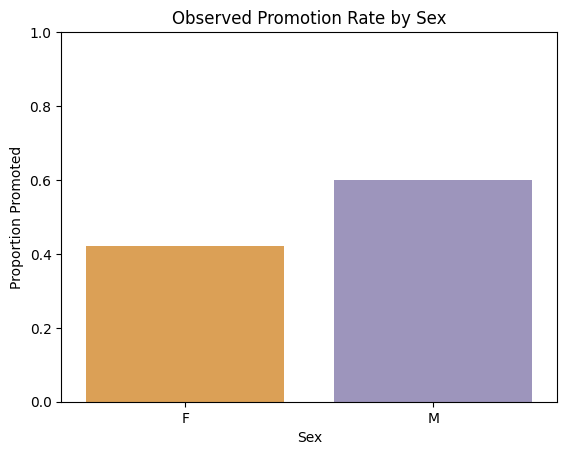

In [21]:
#### CONSTRUCT PLOTTING DATA SET
promotion_rate_by_sex = (
    promotion_summary_df
    .groupby("sex", as_index=False)["promoted"]
    .mean()
    .rename(columns={"promoted": "promotion_rate"}))

#### CREATE PLOT
sns.barplot(
    data=promotion_rate_by_sex,
    x="sex",
    y="promotion_rate",
    hue="sex",
    palette=SEX_COLOR_PALETTE,
    legend=False)

plt.title("Observed Promotion Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion Promoted")
plt.ylim(0, 1)

plt.show()

**Interpretation**

The observed promotion rates suggest a noticeable difference between men and women in the dataset. Approximately 60% of male faculty were promoted to Full Professor compared to about 42% of female faculty, indicating a higher observed promotion rate for men.

To formally quantify this difference and evaluate its statistical significance, we next estimate a simple logistic regression model with sex as the predictor.

### **Simple Logistic Regression: Sex and Promotion**

Before introducing a full multivariable model, we begin with a simple logistic regression
that examines the relationship between sex and promotion from Associate Professor to
Full Professor.

This model answers a straightforward question:

**Are female faculty less likely to be promoted than male faculty when we do not adjust
for any other factors?**

Starting with this unadjusted model helps establish the baseline relationship in the data.
Later, we will extend the model to include additional variables such as field, degree type,
cohort, and years observed. These adjustments allow us to determine whether any observed
difference in promotion rates persists after accounting for other relevant factors.

In [22]:
# Fit simple logistic regression model
simple_logit_model = smf.logit(
    formula="promoted ~ sex",
    data=promotion_summary_df).fit()

simple_logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.674591
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               promoted   No. Observations:                  979
Model:                          Logit   Df Residuals:                      977
Method:                           MLE   Df Model:                            1
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                 0.01731
Time:                        00:24:10   Log-Likelihood:                -660.42
converged:                       True   LL-Null:                       -672.06
Covariance Type:            nonrobust   LLR p-value:                 1.414e-06
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3148      0.132     -2.394      0.017      -0.573      -0.057
sex[T.M]       0.7248      0.151      4.787      0.000       0.428       1.021
==============================================================================
"""

**Convert the coefficient to an odds ratio**

In [23]:
sex_male_log_odds = simple_logit_model.params["sex[T.M]"]
sex_male_conf_int = simple_logit_model.conf_int().loc["sex[T.M]"]
sex_male_p_value = simple_logit_model.pvalues["sex[T.M]"]

odds_ratio = np.exp(sex_male_log_odds)
odds_ratio_conf_interval = np.exp(sex_male_conf_int)

print(f"Odds ratio for male vs female: {odds_ratio:.3f}")
print(
    f"95% CI for odds ratio: "
    f"({odds_ratio_conf_interval[0]:.3f}, {odds_ratio_conf_interval[1]:.3f})")
print(f"P-value for sex effect: {sex_male_p_value:.6f}")

Odds ratio for male vs female: 2.064
95% CI for odds ratio: (1.534, 2.777)
P-value for sex effect: 0.000002


#### Visualizing the Estimated Odds Ratio

To make the regression result easier to interpret, we visualize the estimated odds ratio for promotion comparing male and female faculty. The point represents the estimated odds ratio from the logistic regression model, while the horizontal line shows the 95% confidence interval.

The vertical dashed line at an odds ratio of 1 represents no difference in promotion odds between the two groups. If the confidence interval does not cross this line, it suggests a statistically significant difference in promotion odds.

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


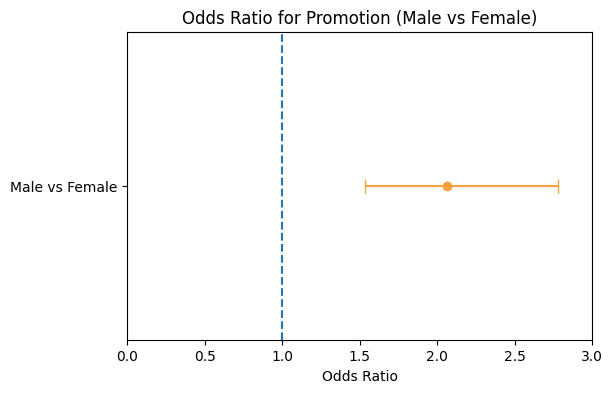

In [24]:
odds_ratio = float(np.exp(simple_logit_model.params["sex[T.M]"]))

conf_int = simple_logit_model.conf_int().loc["sex[T.M]"]
lower_ci = float(np.exp(conf_int.iloc[0]))
upper_ci = float(np.exp(conf_int.iloc[1]))

plot_df = pd.DataFrame({
    "term": ["Male vs Female"],
    "odds_ratio": [odds_ratio],
    "lower": [lower_ci],
    "upper": [upper_ci]})

plt.figure(figsize=(6, 4))

plt.errorbar(
    x=plot_df["odds_ratio"],
    y=plot_df["term"],
    xerr=[plot_df["odds_ratio"] - plot_df["lower"],
          plot_df["upper"] - plot_df["odds_ratio"]],
    fmt="o",
    capsize=5,
    color="#f1a340")

plt.axvline(1, linestyle="--")
plt.xlabel("Odds Ratio")
plt.title("Odds Ratio for Promotion (Male vs Female)")
plt.xlim(0, 3)

plt.show()

**Interpretation of the Odds Ratio Plot**


The estimated odds ratio for promotion comparing male to female faculty is about **2.06**, with a 95% confidence interval from **1.53 to 2.78**. Because the confidence interval does not include 1, the model suggests that promotion odds differ significantly between the two groups.

This visualization reinforces the result from the regression table: in this unadjusted analysis, male faculty appear substantially more likely to be promoted to Full Professor than female faculty.

We now interpret the regression model in more detail.

**Interpretation of the Simple Logistic Regression**

The simple logistic regression model estimates the relationship between sex and the likelihood of promotion to Full Professor. The positive coefficient for `sex[T.M]` indicates that male faculty have higher odds of promotion than female faculty in this unadjusted model.

Exponentiating the coefficient gives an odds ratio of **2.06**, meaning that the odds of promotion for male faculty are estimated to be about **twice the odds for female faculty**. The 95% confidence interval for the odds ratio ranges from **1.53 to 2.78**, and the p-value is very small (p < 0.001), suggesting that this difference in promotion odds is statistically significant.

However, this model does not account for other factors that may influence promotion outcomes, such as academic field, degree type, or hiring cohort. In the next section, we extend the model to include additional variables in order to examine whether this difference persists after adjusting for potential confounders.

### **Logistic regression model**

To evaluate whether sex is associated with the probability of promotion from Associate Professor to Full Professor, we estimate a logistic regression model. Because the outcome of interest is binary (whether a faculty member is promoted during the observation period), logistic regression is an appropriate modeling framework.

The model estimates the probability that a faculty member is promoted as a function of demographic and career characteristics.


$$
\text{logit}(p_i)
=
\beta_0
+
\beta_1\,\text{Sex}_i
+
\beta_2\,\text{AssocYearsObserved}_i
+
\beta_3\,\text{Field}_i
+
\beta_4\,\text{Degree}_i
+
\beta_5\,\text{Cohort}_i
$$


where \(p_i\) is the probability that faculty member \(i\) is promoted to Full Professor during the observation period.

The variables included in the model are defined as follows:

- **Sex (`sex`)**  
  Indicator variable equal to 1 if the faculty member is female and 0 if male. The coefficient for this variable represents the association between sex and the probability of promotion after adjusting for other factors in the model.

- **Years observed at Associate (`assoc_yrs_observed`)**  
  The number of years a faculty member is observed at the Associate Professor rank within the dataset. Because the dataset has a fixed observation window (1976–1995), this measure represents observed time at rank rather than true time at rank. Some faculty may have entered the Associate rank before the dataset begins (left censoring), and some faculty who are not promoted during the study period may be promoted after the dataset ends (right censoring). Despite these limitations, including this variable helps account for differences in exposure time when modeling the probability of promotion.

- **Field (`field`)**  
  Academic discipline categories included as indicator variables. Promotion practices and timelines can differ substantially across fields, so including field helps control for disciplinary differences.

- **Degree type (`deg`)**  
  Highest degree earned by the faculty member. Degree type may reflect differences in career paths or institutional expectations that could influence promotion outcomes.

- **Associate cohort (`assoc_cohort`)**  
  A categorical variable based on the first observed Associate Professor year. This variable accounts for differences in promotion environments across historical periods rather than treating calendar year as a purely linear effect.

The categorical variables (`field`, `deg`, and `assoc_cohort`) are included in the model using indicator variables, allowing promotion probabilities to vary across categories without imposing a linear structure.

The coefficient associated with **sex** is the primary quantity of interest. It measures the difference in the log-odds of promotion between male and female faculty after adjusting for career stage, discipline, degree type, and cohort effects.

</div>

#### **Logistic Regression Assumptions**

Before fitting the multiple logistic regression model, we briefly consider the main assumptions of logistic regression and how they apply to this analysis.

*Binary outcome* <br>
Logistic regression requires the dependent variable to be binary. In this dataset, the outcome variable `promoted` indicates whether a faculty member was promoted to Full Professor during the observation period (1 = promoted, 0 = not promoted), satisfying this requirement.

*Independent observations*  <br>
Each observation represents a distinct faculty member, and the dataset does not include repeated measurements of the same individual. The observations can therefore reasonably be treated as independent.

*No strong multicollinearity among predictors* <br>
Predictor variables should not be highly correlated with one another, as strong correlations can inflate the variance of coefficient estimates and make model results unstable. We evaluate this assumption using Variance Inflation Factors (VIFs), which are calculated in the following section.

*Linear relationship between continuous predictors and the log-odds of the outcome*  <br>
Logistic regression assumes that continuous predictors have an approximately linear relationship with the log-odds of the outcome. In this model, the only continuous predictor is `assoc_yrs_observed`, which represents the number of years a faculty member is observed at the Associate rank.

*Adequate sample size* <br>
Logistic regression requires sufficient observations relative to the number of predictors. With 979 faculty members in the dataset, the sample size is large relative to the number of model parameters, supporting stable estimation of the regression coefficients.

##### **Checking for Multicollinearity**

Before fitting the multiple logistic regression model, we check for **multicollinearity** among the predictor variables. Multicollinearity occurs when predictors are highly correlated with one another, which can make coefficient estimates unstable and difficult to interpret.

To assess this, we compute Variance Inflation Factors (VIFs) for the predictors in the model. VIF values measure how much the variance of a coefficient estimate is inflated due to correlations with other predictors. As a general guideline, VIF values below about 5 indicate that multicollinearity is not a major concern.

In [25]:
# Define the model formula used in the regression
promotion_model_formula = (
    "promoted ~ sex + assoc_yrs_observed + field + deg + assoc_cohort")

# Create the response and predictor design matrices
response_matrix, predictor_matrix = dmatrices(
    promotion_model_formula,
    data=promotion_summary_df,
    return_type="dataframe")

# Compute variance inflation factors
vif_results_df = pd.DataFrame({
    "variable": predictor_matrix.columns,
    "VIF": [variance_inflation_factor(
            predictor_matrix.values,
            column_index)
        for column_index in range(predictor_matrix.shape[1])]})

vif_results_df

,variable,VIF
0,Intercept,22.745493
1,sex[T.M],1.085164
2,field[T.Other],1.910449
3,field[T.Prof],1.963604
4,deg[T.PhD],1.532836
5,deg[T.Prof],1.514552
6,assoc_cohort[T.81-85],1.272791
7,assoc_cohort[T.86-90],1.336001
8,assoc_cohort[T.91-95],1.611981
9,assoc_yrs_observed,1.277120


##### **Visualizing Variance Inflation Factors**

To complement the VIF table, the figure below visualizes the variance inflation factors for each predictor in the model. Each bar represents the VIF value for a predictor, and the dashed vertical line indicates a commonly used threshold of 5, above which multicollinearity may become a concern.

Visualizing the VIF values helps make it easier to see whether any predictors stand out as potentially problematic due to strong correlations with other variables in the model.

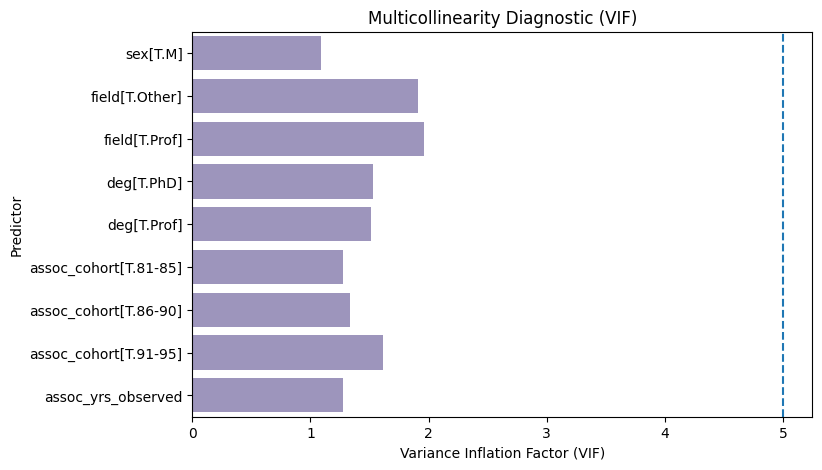

In [26]:
# Remove intercept for visualization
vif_plot_df = vif_results_df[vif_results_df["variable"] != "Intercept"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=vif_plot_df,
    x="VIF",
    y="variable",
    color="#998ec3"
)

plt.axvline(5, linestyle="--")
plt.xlabel("Variance Inflation Factor (VIF)")
plt.ylabel("Predictor")
plt.title("Multicollinearity Diagnostic (VIF)")

plt.show()

##### **Interpretation**

The VIF values for all predictors are close to 1 and well below the commonly used threshold of 5. This indicates that the predictors in the model are not strongly correlated with one another, and multicollinearity is unlikely to substantially affect the stability or interpretation of the logistic regression coefficients.

### **Fit the Logistic Regression**

$$
\text{logit}(p_i)
=
\beta_0
+
\beta_1\,\text{Sex}_i
+
\beta_2\,\text{AssocYearsObserved}_i
+
\beta_3\,\text{Field}_i
+
\beta_4\,\text{Degree}_i
+
\beta_5\,\text{Cohort}_i
$$

In [27]:
promotion_model_formula = ("promoted ~ sex + assoc_yrs_observed + field + deg + assoc_cohort")

multiple_logit_model = smf.logit(
    formula=promotion_model_formula,
    data=promotion_summary_df).fit()

####
# View the output
####
multiple_logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.216888
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               promoted   No. Observations:                  979
Model:                          Logit   Df Residuals:                      969
Method:                           MLE   Df Model:                            9
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.6841
Time:                        00:24:11   Log-Likelihood:                -212.33
converged:                       True   LL-Null:                       -672.06
Covariance Type:            nonrobust   LLR p-value:                3.999e-192
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                12.7611      1.312      9.726      0.000      10.189      15.333
sex[T.M]                  0.5356      0.282      1.901      0.057      -0.016       1.088
field[T.Other]            0.4780      0.348      1.374      0.170      -0.204       1.160
field[T.Prof]             0.1614      0.446      0.362      0.717      -0.712       1.035
deg[T.PhD]                0.2569      0.385      0.667      0.504      -0.498       1.011
deg[T.Prof]              -0.5204      0.631     -0.824      0.410      -1.758       0.717
assoc_cohort[T.81-85]    -4.0427      0.602     -6.717      0.000      -5.222      -2.863
assoc_cohort[T.86-90]    -8.4326      0.892     -9.456      0.000     -10.180      -6.685
assoc_cohort[T.91-95]   -15.2692      1.289    -11.846      0.000     -17.796     -12.743
assoc_yrs_observed       -0.9467      0.083    -11.355      0.000      -1.110      -0.783
=========================================================================================

Possibly complete quasi-separation: A fraction 0.18 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [28]:
odds_ratio_table_df = pd.DataFrame({
    "variable": multiple_logit_model.params.index,
    "odds_ratio": np.exp(multiple_logit_model.params),
    "lower_ci": np.exp(multiple_logit_model.conf_int()[0]),
    "upper_ci": np.exp(multiple_logit_model.conf_int()[1]),
    "p_value": multiple_logit_model.pvalues}).reset_index(drop=True)

odds_ratio_table_df = odds_ratio_table_df.round(3)

####
# View the output
####
odds_ratio_table_df

,variable,odds_ratio,lower_ci,upper_ci,p_value
0,Intercept,348380.644,26618.251,4559618.693,0.000
1,sex[T.M],1.708,0.984,2.967,0.057
2,field[T.Other],1.613,0.815,3.190,0.170
3,field[T.Prof],1.175,0.491,2.815,0.717
4,deg[T.PhD],1.293,0.608,2.749,0.504
5,deg[T.Prof],0.594,0.172,2.048,0.410
6,assoc_cohort[T.81-85],0.018,0.005,0.057,0.000
7,assoc_cohort[T.86-90],0.000,0.000,0.001,0.000
8,assoc_cohort[T.91-95],0.000,0.000,0.000,0.000
9,assoc_yrs_observed,0.388,0.330,0.457,0.000


### **Interpretation of the Multiple Logistic Regression Model**

The multiple logistic regression model estimates the probability of promotion to Full Professor as a function of sex, years observed at the Associate rank, academic field, degree type, and associate cohort.

After adjusting for these factors, the estimated odds ratio comparing male to female faculty is **1.71**. This suggests that male faculty have approximately **71% higher odds of promotion** than female faculty with similar career characteristics.

However, the 95% confidence interval for this estimate ranges from **0.98 to 2.97**, and the p-value is **0.057**. Because the confidence interval includes 1 and the p-value is slightly above the conventional 0.05 threshold, this adjusted association is **not statistically significant at the 5% level**.

Compared with the simple logistic regression earlier in the analysis, the magnitude of the sex effect decreases after adjusting for other factors, suggesting that differences in career stage, discipline, degree type, and cohort explain part of the observed difference in promotion rates.

</div>

### **Visualizing the Strongest Predictors of Promotion**

The multiple logistic regression results indicate that the strongest predictors of promotion are the **associate cohort** and the **number of years observed at the Associate rank**. These variables capture differences in opportunity for promotion across historical periods and across time spent at rank.

To better understand these relationships, we visualize predicted promotion probabilities by **associate cohort and sex**. This allows us to examine how promotion outcomes vary across cohorts while comparing patterns between male and female faculty.

**Create Predition Dataset across Cohort and Sex**

In [29]:
median_years_observed = promotion_summary_df["assoc_yrs_observed"].median()
mode_field = promotion_summary_df["field"].mode()[0]
mode_degree = promotion_summary_df["deg"].mode()[0]

prediction_df = pd.DataFrame({
    "sex": ["F","F","F","F","M","M","M","M"],
    "assoc_cohort": [
        "76-80","81-85","86-90","91-95",
        "76-80","81-85","86-90","91-95"],
    "assoc_yrs_observed": [median_years_observed]*8,
    "field": [mode_field]*8,
    "deg": [mode_degree]*8})

prediction_df["predicted_promotion_probability"] = (
    multiple_logit_model.predict(prediction_df))

prediction_df

,sex,assoc_cohort,assoc_yrs_observed,field,deg,predicted_promotion_probability
0,F,76-80,4.0,Other,PhD,0.999939
1,F,81-85,4.0,Other,PhD,0.996552
2,F,86-90,4.0,Other,PhD,0.781862
3,F,91-95,4.0,Other,PhD,0.003834
4,M,76-80,4.0,Other,PhD,0.999964
5,M,81-85,4.0,Other,PhD,0.997979
6,M,86-90,4.0,Other,PhD,0.859620
7,M,91-95,4.0,Other,PhD,0.006533


**Plot Predicted Promotion Probability by Cohort and Sex**

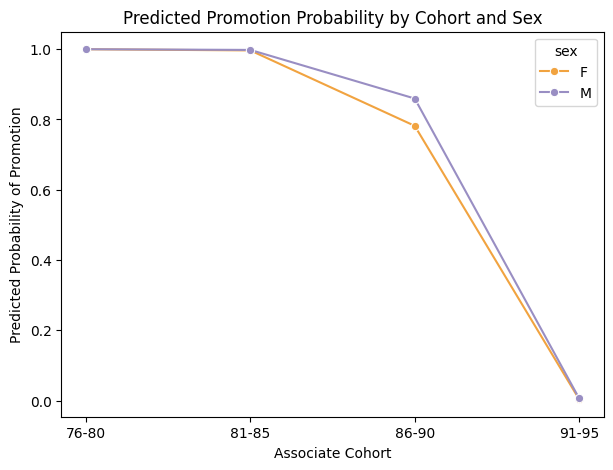

In [30]:
plt.figure(figsize=(7,5))

sns.lineplot(
    data=prediction_df,
    x="assoc_cohort",
    y="predicted_promotion_probability",
    hue="sex",
    marker="o",
    palette=SEX_COLOR_PALETTE)

plt.ylabel("Predicted Probability of Promotion")
plt.xlabel("Associate Cohort")
plt.title("Predicted Promotion Probability by Cohort and Sex")

plt.show()

**Interpretation**

Predicted promotion probabilities vary strongly across associate cohorts. Earlier cohorts have very high predicted promotion probabilities because they have had more time within the observation window to be promoted, while more recent cohorts have much lower predicted probabilities due to limited follow-up time in the dataset.

The extremely low predicted probability for the 1991–1995 cohort reflects the structure of the dataset rather than a substantive difference in promotion outcomes. Faculty in this cohort were observed for only a short period before the dataset ends in 1995, meaning many individuals who were not promoted during the observation window may have been promoted later.

Within each cohort, the predicted promotion probabilities for male and female faculty are relatively similar. This pattern is consistent with the multiple logistic regression results, where the adjusted effect of sex is smaller than the effects associated with cohort and time observed at rank.

##### **Observed Promotion Rates By time cohort and sex**

In [31]:
promotion_rates = (
    promotion_summary_df
    .groupby(["assoc_cohort", "sex"], observed=True)["promoted"]
    .mean()
    .reset_index())

promotion_rates

,assoc_cohort,sex,promoted
0,76-80,F,0.791667
1,76-80,M,0.778878
2,81-85,F,0.653061
3,81-85,M,0.769784
4,86-90,F,0.500000
5,86-90,M,0.564417
6,91-95,F,0.012195
7,91-95,M,0.080292


#### **Plot promotion rates by cohort and sex**

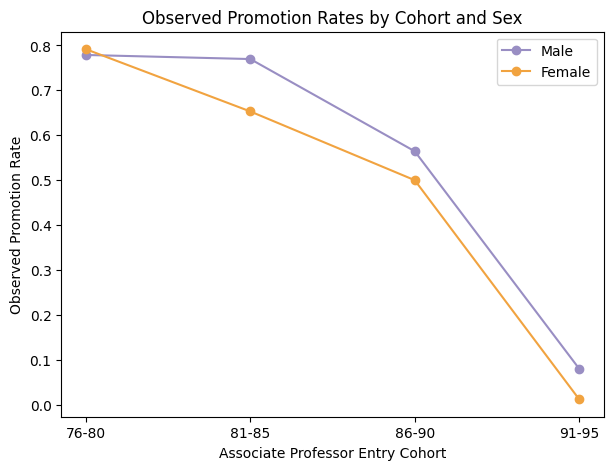

In [32]:
plt.figure(figsize=(7,5))

for sex_value, label in [("M", "Male"), ("F", "Female")]:

    subset = promotion_rates[promotion_rates["sex"] == sex_value]

    plt.plot(
        subset["assoc_cohort"],
        subset["promoted"],
        marker="o",
        label=label,
        color=SEX_COLOR_PALETTE[sex_value])

plt.xlabel("Associate Professor Entry Cohort")
plt.ylabel("Observed Promotion Rate")
plt.title("Observed Promotion Rates by Cohort and Sex")

plt.legend()

plt.show()

**Interpretation**

The observed promotion rates show a strong decline across associate cohorts. Faculty who entered the Associate rank in earlier cohorts have much higher promotion rates than those in later cohorts. This pattern reflects the limited observation window of the dataset, which ends in 1995. Faculty in more recent cohorts have had less time to be promoted within the dataset, leading to lower observed promotion rates.

Within each cohort, promotion rates for male and female faculty follow broadly similar patterns, although male faculty have slightly higher promotion rates in most cohorts. These observed patterns are consistent with the regression results, which suggest that cohort and time observed at rank are stronger predictors of promotion than sex after adjusting for other factors.

___
# Time to promotion
___

While the previous analysis examined whether faculty were promoted during the observation period, it does not capture differences in how long promotion takes. Even if promotion rates are similar across groups, systematic differences in the time required to reach promotion could still represent an important form of inequality.

To investigate this possibility, we analyze the number of years between a faculty member's first observed year at the Associate Professor rank and their first observed year at the Full Professor rank. This quantity is recorded in the variable `yrs_to_promo`.

**Dataset**<br>
Because this analysis requires identifying the exact promotion year, it is restricted to faculty with clean Associate-to-Full transitions, where the final Associate observation occurs in the year immediately preceding the first Full observation. This restriction ensures that the promotion timing is measured accurately.

**Linear Regression**<br>
To examine whether time to promotion differs systematically across groups, we estimate a linear regression model using `yrs_to_promo` as the outcome variable. Because time to promotion is a continuous quantity measured in years, linear regression provides a natural framework for modeling how expected promotion timing varies with faculty characteristics. The coefficients in the model represent the expected change in years to promotion associated with each predictor while holding other variables constant.

</div>

**Dataset for Time to Promotion Analysis**

In [33]:
time_to_promo_df = promotion_summary_df[
    (promotion_summary_df["promoted"] == True) &
    (promotion_summary_df["clean_assoc_full_transition"] == True)].copy()

print("Number of faculty in time-to-promotion dataset:", time_to_promo_df.shape[0])

Number of faculty in time-to-promotion dataset: 533


Before estimating a regression model for time to promotion, we first visualize the distribution of promotion timing. Examining the data graphically helps identify differences in central tendency, variability, and potential outliers across groups. The following plot shows the distribution of years to promotion from Associate Professor to Full Professor by sex.

In [34]:
time_to_promo_df.groupby("sex")["yrs_to_promo"].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
F,100.0,6.220000,2.468304,1.0,5.0,6.0,7.0,13.0
M,433.0,5.639723,3.168054,1.0,4.0,5.0,7.0,18.0


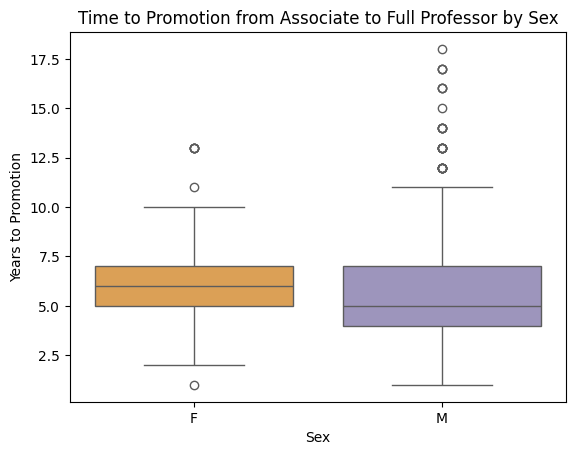

In [35]:
plt.figure()

sns.boxplot(
    data=time_to_promo_df,
    x="sex",
    y="yrs_to_promo",
    order=["F", "M"],
    hue = "sex",
    palette=SEX_COLOR_PALETTE
)

plt.xlabel("Sex")
plt.ylabel("Years to Promotion")
plt.title("Time to Promotion from Associate to Full Professor by Sex")

plt.show()

**Interpretation**

The distribution of time to promotion appears broadly similar for male and female faculty. The median time to promotion for both groups is around five to six years, although the male group shows slightly greater variability and a larger number of high outliers representing longer promotion times. Overall, the visualization does not suggest a large difference in typical promotion timing between the two groups, but formal modeling will help evaluate whether systematic differences remain after accounting for other factors.

### **Assessing Linear Regression Assumptions**

Before fitting the linear regression model for time to promotion, we briefly evaluate whether the data are appropriate for a linear regression framework.

*Linearity* <br>
Linear regression assumes a linear relationship between predictors and the outcome variable. In this analysis, the predictors are primarily categorical variables (sex, field, degree type, and cohort), which represent group differences rather than continuous trends. This structure is compatible with the linear model.
<br>
<br>
*Independence of observations* <br>
Each observation corresponds to a distinct faculty member, and the dataset does not include repeated measurements for individuals. This supports the assumption that observations are independent.
<br>
<br>
*Multicollinearity* <br>
Predictors should not be highly correlated with one another. This assumption was previously evaluated using variance inflation factors (VIFs), which indicated no evidence of problematic multicollinearity among the predictors used in this model.

## **Linear regression model for time to promotion**

To examine whether male and female faculty differ in how long it takes to reach promotion, we estimate a linear regression model with the number of years required to move from Associate Professor to Full Professor as the outcome variable.

The model takes the form:

$$
yrs\_to\_promo_i =
\beta_0 +
\beta_1\,Sex_i +
\beta_2\,Field_i +
\beta_3\,Degree_i +
\beta_4\,Cohort_i +
\epsilon_i
$$

where:

- **`yrs_to_promo`** measures the number of years between the first observed Associate Professor year and the first observed Full Professor year.
- **`sex`** indicates whether the faculty member is male or female.
- **`field`** accounts for disciplinary differences in promotion timelines.
- **`deg`** controls for differences in degree type.
- **`assoc_cohort`** accounts for differences across historical promotion cohorts.

The coefficient on the sex variable measures the average difference in years to promotion between male and female faculty after controlling for these factors.

</div>

#### Setup Linear Regression

In [36]:
time_to_promotion_model = smf.ols(
    formula="""
    yrs_to_promo ~ sex + field + deg + assoc_cohort
    """,
    data=time_to_promo_df).fit()

print(time_to_promotion_model.summary())

                            OLS Regression Results                            
Dep. Variable:           yrs_to_promo   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     3.550
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           0.000511
Time:                        00:24:11   Log-Likelihood:                -1337.0
No. Observations:                 533   AIC:                             2692.
Df Residuals:                     524   BIC:                             2731.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.15

### **Check Residual Diagnostics**
*Homoscedasticity (constant variance of residuals)*<br>
Linear regression assumes that the variance of the residuals is roughly constant across levels of the predictors. We examine this using residual diagnostic plots.

*Normality of residuals*<br>
For valid inference, the residuals of the model should be approximately normally distributed. This assumption will be evaluated using a Q–Q plot of the residuals.

##### Extract Fitted Values and Residuals

In [37]:
fitted_values = time_to_promotion_model.fittedvalues
model_residuals = time_to_promotion_model.resid

**Plot Residuals vs Fitted Values (Homoscedasticty check)**

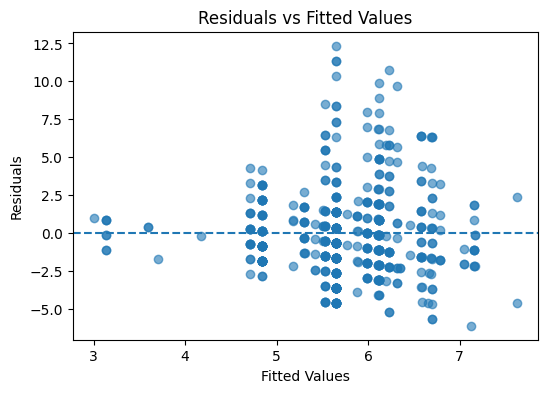

In [38]:
plt.figure(figsize=(6,4))

plt.scatter(
    fitted_values,
    model_residuals,
    alpha=0.6)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

**Q-Q Plot (normality check)**

<Figure size 600x400 with 0 Axes>

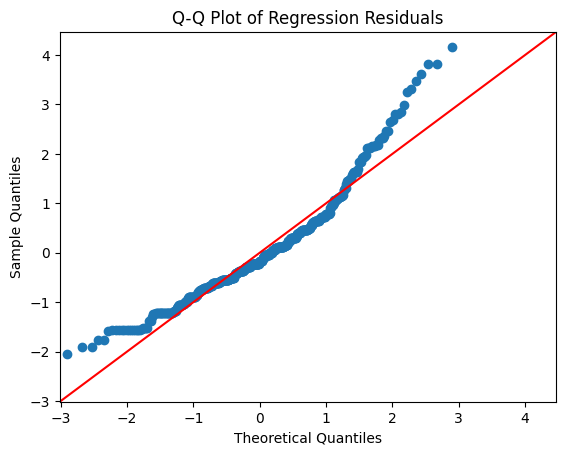

In [39]:
plt.figure(figsize=(6,4))

sm.qqplot(
    model_residuals,
    line="45",
    fit=True)

plt.title("Q-Q Plot of Regression Residuals")

plt.show()

#### **Residual diagnostics interpretation**

The **residuals versus fitted values plot** shows that residuals are generally centered around zero without a strong systematic pattern. While the spread of residuals appears somewhat larger around the middle fitted values, there is no clear funnel shape, suggesting that the homoscedasticity assumption is reasonably satisfied.

The **Q–Q plot** indicates that the residuals follow the reference line fairly closely through the center of the distribution, although there is some deviation in the upper tail. This suggests mild departures from normality driven by a small number of larger positive residuals. These upper tail observations likely correspond to faculty who took unusually long to be promoted, which is consistent with the outliers observed earlier in the boxplot of time to promotion.

Overall, the residual diagnostics suggest that the assumptions of homoscedasticity and approximate normality are sufficiently satisfied to proceed with interpretation of the linear regression results.

### **Interpretation of the linear regression model**

The linear regression model estimates how faculty characteristics are associated with the number of years required to move from Associate Professor to Full Professor.

After adjusting for field, degree type, and cohort, the estimated difference in time to promotion between male and female faculty is −0.46 years (95% CI: −1.13 to 0.21, p = 0.18). This effect size corresponds to roughly **five to six months faster promotion for male faculty on average**, although the confidence interval includes zero. As a result, the model does not provide statistical evidence of a systematic difference in promotion timing between male and female faculty.

Among the other predictors, cohort appears to have the strongest association with promotion timing. Faculty in later cohorts tend to reach promotion more quickly than those in the earliest cohort. In particular, the 1986–1990 cohort is estimated to reach promotion about 0.81 years faster (p = 0.015), and the 1991–1995 cohort about 2.52 years faster (p = 0.005), relative to the 1976–1980 cohort.

Overall, the model explains a relatively small portion of the variation in promotion timing (R² = 0.051), indicating that most of the variability in time to promotion is likely driven by factors not captured in the model.

### Time to promotion by cohort

The regression results suggest that faculty in later cohorts tend to reach promotion more quickly than those in earlier cohorts. To better understand this pattern, we visualize the distribution of time to promotion across Associate Professor entry cohorts.

The following plot shows the distribution of years required to move from Associate Professor to Full Professor for each cohort in the dataset.

**Plotting Time to Promotion by Cohort and Sex**

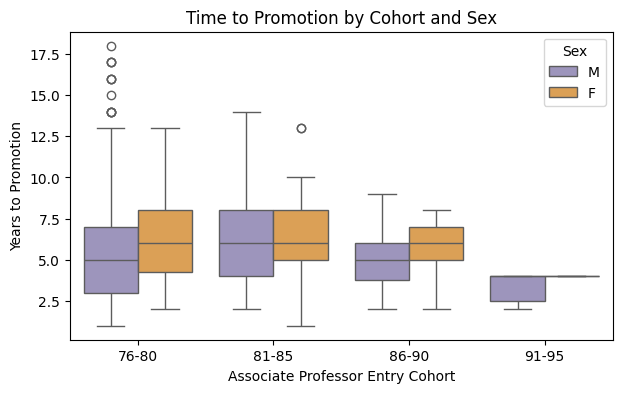

In [40]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=time_to_promo_df,
    x="assoc_cohort",
    y="yrs_to_promo",
    hue="sex",
    palette=SEX_COLOR_PALETTE)

plt.xlabel("Associate Professor Entry Cohort")
plt.ylabel("Years to Promotion")
plt.title("Time to Promotion by Cohort and Sex")

plt.legend(title="Sex")

plt.show()

**Interpretation**

Across cohorts, later groups generally appear to reach promotion more quickly than earlier cohorts, which is consistent with the regression results showing shorter promotion times for more recent cohorts. Within each cohort, the distributions of time to promotion for male and female faculty are broadly similar and show substantial overlap. This visual pattern reinforces the regression finding that differences in promotion timing between men and women are relatively small compared to the overall cohort effects.

---

# **Salary Differences At promotion**

---

### Additional Subset of data

#### Calculate the difference in promotion salary and previous salary without Cohort assignments

In order to see if there is wage discrimination in granting promotions from Associate Professor to Full
Professor, we want to look at the increase in salary individuals recieve after a pormotion.

Steps we took:
1.  Sorted the cleaned dataframe by 'id' and 'year'.
2. Got the previous rank and salary within each id
3. Selected rows were current rank is 'Full' and previous is 'Assoc'.
4. Subtract previous salary from salary of promotion

This dataframe better allows use to view the average change in salary in each specific year.

In [41]:
sorted_df = salary_long_df.sort_values(by=["id","year"])

sorted_df["prev_rank"]   = sorted_df.groupby("id")["rank"].shift()
sorted_df["prev_salary"] = sorted_df.groupby("id")["salary"].shift()

promotions_df = sorted_df[(sorted_df["rank"] == "Full") & (sorted_df["prev_rank"] == "Assoc")]


promotions_df["promotion_diff"] = promotions_df["salary"] - promotions_df["prev_salary"]

promotions_df.head()

/tmp/ipykernel_340/3139905583.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promotions_df["promotion_diff"] = promotions_df["salary"] - promotions_df["prev_salary"]


,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary,rank_order,prev_rank,prev_salary,promotion_diff
49,53,10,M,PhD,68,Arts,80,93,Full,1,7180.0,3,Assoc,6781.0,399.0
78,82,13,M,PhD,68,Prof,69,82,Full,0,3322.0,3,Assoc,3137.0,185.0
94,98,14,M,PhD,79,Other,92,94,Full,0,9025.0,3,Assoc,8770.0,255.0
111,115,16,M,PhD,73,Other,79,89,Full,0,5290.0,3,Assoc,4538.0,752.0
125,129,17,M,PhD,72,Other,72,83,Full,0,2994.0,3,Assoc,2838.0,156.0


#### Year vs Average Change in Salary After Promotion Line Plot by Gender

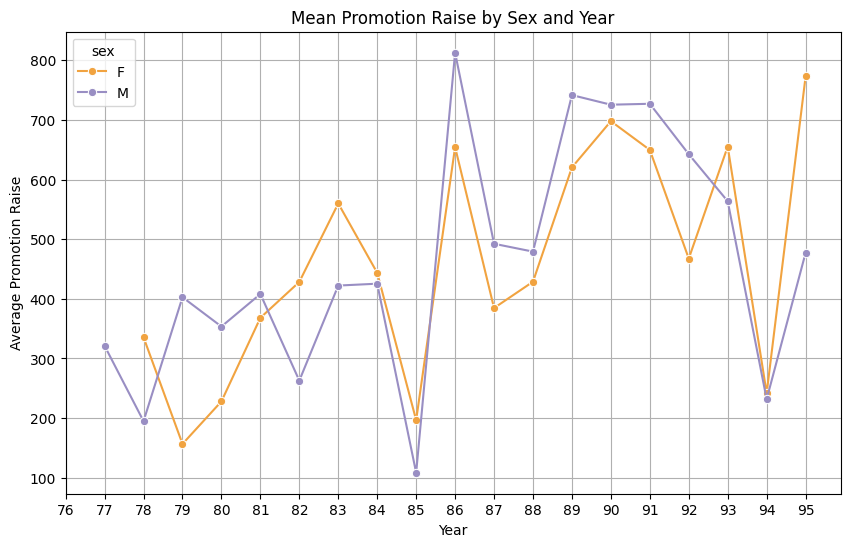

In [42]:
prom_by_year = promotions_df.groupby(['sex', 'year'])['promotion_diff'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=prom_by_year,
    x="year",
    y="promotion_diff",
    hue="sex", palette=SEX_COLOR_PALETTE,
    marker="o")

plt.xlabel("Year")
plt.ylabel("Average Promotion Raise")
plt.title("Mean Promotion Raise by Sex and Year")
plt.xticks(np.arange(76, 96, 1))
plt.grid(True)

plt.show()

### Line Plot Interpretation:

The line plot above shows the mean "promotion salary difference" of males and females by year of promotion. While both time series lines show similar overall patters, there is no sustained period where one sex outperforms the other. The lines move in the same direction near the same times, suggesting that shared influences on promotion raise values. Eventhough there are some areas where one line is above the other, the overall comparison does not indicate a stable or systematic difference in promotion salry difference between sexes.

#### Boxplot

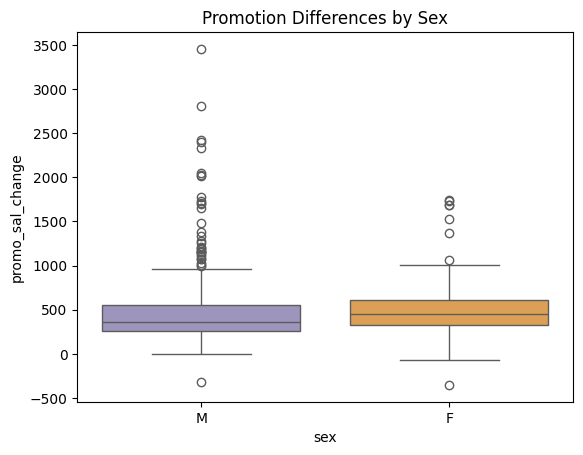

In [44]:
sns.boxplot(data=promotion_summary_df,
            x="sex",
            y="promo_sal_change",
            hue="sex", palette=SEX_COLOR_PALETTE)
plt.title("Promotion Differences by Sex")
plt.show()

**Interpretation**

The graph above shows that although men have more extreme values, the 25-75 quartile range of promotion differences in salary is very similr. Most individuals have a 450-500 dollar increase in their monthly salary when they are promoted. This suggest that there are not significant differences in salaries with men vs women.

#### ScatterPlot
Previous Salary vs Raise


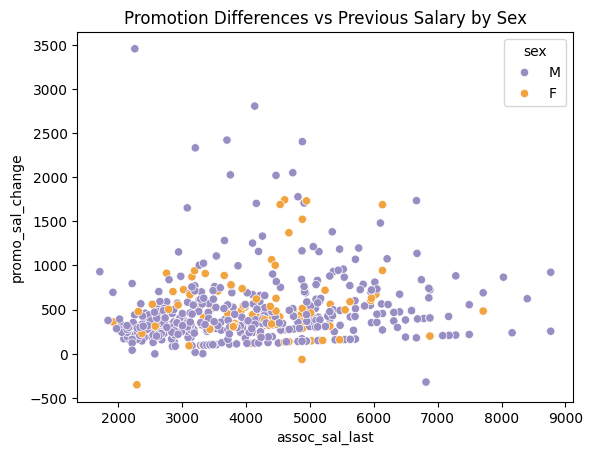

In [45]:
# # prev salary vs raise
sns.scatterplot(data=promotion_summary_df,
                x="assoc_sal_last",
                y="promo_sal_change",
                hue="sex", palette=SEX_COLOR_PALETTE)
plt.title("Promotion Differences vs Previous Salary by Sex")
plt.show()

**Interpretation**

The scatterplot of previous salary versus promotion raise shows a generally weak positive association, where larger raises tend to occur at somewhat higher previous salaries but with substantial variability. Points for men and women are intermingled across the range of both axes, and neither color dominates in any particular region of the plot. This visual pattern suggests that promotion raises increase only slightly with prior salary and that the relationship between previous salary and raise is broadly similar for men and women, without a clear indication that one group systematically receives larger raises than the other.

#### Boxplot

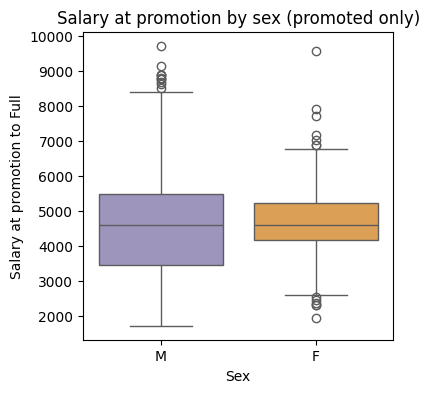

In [46]:
plt.figure(figsize=(4,4))
sns.boxplot(data=promotion_summary_df,
            x="sex", y="assoc_sal_last",
            hue="sex", palette=SEX_COLOR_PALETTE)
plt.xlabel("Sex")
plt.ylabel("Salary at promotion to Full")
plt.title("Salary at promotion by sex (promoted only)")
plt.show()

**Interpretation**

Salaries at promotion appear broadly similar for men and women. The medians are close, and the middle 50% of salaries spans a comparable range in both groups, though men show more extreme high salary outliers. This suggests that, conditional on being promoted, men and women tend to receive roughly comparable salaries at the time of promotion.

#### Countplot

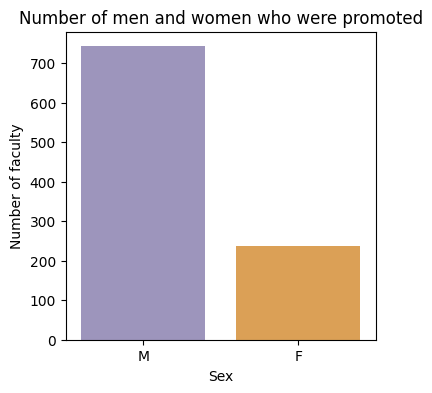

In [48]:
plt.figure(figsize=(4,4))
sns.countplot(data=promotion_summary_df, x="sex",
              hue="sex", palette=SEX_COLOR_PALETTE)
plt.xlabel("Sex")
plt.ylabel("Number of faculty")
plt.title("Number of men and women who were promoted")
plt.show()

**Interpretation**

The number of men promoted is much larger than the number of women. The bar for men is several times taller, indicating that far more men than women reach promotion in this dataset. This pattern suggests that gender differences are more pronounced in promotion likelihood than in salary levels among those who are promoted.

### Linear Regression on Amount of Change in Salary after Promotion

In [49]:
promotions_df["raise_pct"] = promotions_df["promotion_diff"] / promotions_df["prev_salary"]

mod = smf.ols("promotion_diff ~ C(sex) + C(field) + C(deg) + startyr + yrdeg", data=promotions_df).fit()
mod.summary()

/tmp/ipykernel_340/1596578240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promotions_df["raise_pct"] = promotions_df["promotion_diff"] / promotions_df["prev_salary"]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         promotion_diff   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     6.445
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.64e-07
Time:                        00:28:11   Log-Likelihood:                -4010.6
No. Observations:                 546   AIC:                             8037.
Df Residuals:                     538   BIC:                             8072.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -714.2866    214.071     -3.337      0.001   -1134.804    -293.770
C(sex)[T.M]         -25.7714     43.015     -0.599      0.549    -110.270      58.727
C(field)[T.Other]   -93.1741     49.906     -1.867      0.062    -191.209       4.861
C(field)[T.Prof]     -1.1372     59.155     -0.019      0.985    -117.341     115.067
C(deg)[T.PhD]        23.3103     66.126      0.353      0.725    -106.586     153.206
C(deg)[T.Prof]       -8.4780     96.885     -0.088      0.930    -198.797     181.841
startyr               5.2900      3.816      1.386      0.166      -2.205      12.785
yrdeg                11.6525      4.529      2.573      0.010       2.756      20.549
==============================================================================
Omnibus:                      366.923   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4794.919
Skew:                           2.806   Prob(JB):                         0.00
Kurtosis:                      16.389   Cond. No.                     1.41e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.41e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interpretation
When fitting the linear regression model on the amount of bonus that is received after promotion from Associate to Full professor, we can see that the coefficient for sex is -25.9132. At face value, this would indicate that when a male professor is promoted, their salary will be -25.9132 dollars less than a female professors, given that field, degree, start year, and year are controlled.

However, the associated p-value of 0.547 indicates that this difference is not statistically significant. Since the p-value is well above the standard 0.05 threshold and the confidence interval includes zero, we fail to reject the null hypothesis. Consequently, the data does not provide sufficient evidence to conclude that sex has a meaningful effect on the salary increase after promotion when other variables are held constant.

We cannot conclude that a gender-based pay gap exists in this specific promotion bonus context based on this model.


### Conclusion (state effect size, biggest contributors to difference/variation, statistical significance)
Overall, our descriptive plots and regression model suggest that there is little evidence of a systematic gender-based pay gap in promotion raises in this dataset once other factors are controlled. The visualizations show that men and women who are promoted receive broadly similar salaries at promotion and similar promotion increases across previous salary levels and over time. The regression coefficient for sex is small, negative, and not statistically significant, and its confidence interval includes zero, indicating that—after adjusting for field, degree, start year, and year of promotion—sex is not a meaningful predictor of the promotion bonus. At the same time, the bar plot of promotion counts reveals that substantially fewer women than men are promoted, implying that any gender disparity in this setting appears to arise more from differences in who is promoted than from differences in how much they are paid when promotion occurs.

### Overall Summary

